In [11]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# Parameters
n_transactions = 5000
n_customers = 500

# 1. Generate Customer IDs
customer_ids = [f"NG-CUST-{i:04d}" for i in range(1, n_customers + 1)]
random_customers = np.random.choice(customer_ids, size=n_transactions)

# 2. Generate Invoice Dates (spanning 1 year)
start_date = pd.to_datetime("2023-01-01")
end_date = pd.to_datetime("2023-12-31")
random_dates = start_date + pd.to_timedelta(
    np.random.randint(0, int((end_date - start_date).total_seconds()), size=n_transactions),
    unit="s",
)

# 3. Generate Transaction Types & Channels (Nigerian Context)
tx_types = ["In-Store Purchase", "Online Order", "Utility Bill", "Bulk Purchase"]
tx_type_probs = [0.55, 0.30, 0.10, 0.05]
random_types = np.random.choice(tx_types, size=n_transactions, p=tx_type_probs)

channels = ["POS Terminal", "Bank Transfer", "Web Checkout", "USSD", "Cash"]
channel_probs = [0.45, 0.25, 0.15, 0.10, 0.05]
random_channels = np.random.choice(channels, size=n_transactions, p=channel_probs)

# 4. Generate Amount Spent in NGN (Realistic distribution with low/mid/high spenders)
amounts = np.random.exponential(scale=15000, size=n_transactions) + 1200
amounts = np.round(amounts, 2)

# 5. Generate Locations (Major Nigerian Cities)
locations = ["Lagos", "Kano", "Ibadan", "Abuja", "Port Harcourt", "Kaduna", "Enugu"]
loc_probs = [0.40, 0.15, 0.15, 0.10, 0.10, 0.05, 0.05]
random_locations = np.random.choice(locations, size=n_transactions, p=loc_probs)

# Build DataFrame
df = pd.DataFrame(
    {
        "Invoice_ID": [f"INV-NG-{i:06d}" for i in range(1, n_transactions + 1)],
        "Customer_ID": random_customers,
        "Invoice_Date": random_dates,
        "Amount_Spent_NGN": amounts,
        "Transaction_Type": random_types,
        "Payment_Channel": random_channels,
        "Location": random_locations,
    }
)

# Save to CSV for submission repo
df.to_csv("nigerian_retail_transactions.csv", index=False)
print("Dataset created successfully! Shape:", df.shape)
df.head()

Dataset created successfully! Shape: (5000, 7)


,Invoice_ID,Customer_ID,Invoice_Date,Amount_Spent_NGN,Transaction_Type,Payment_Channel,Location
0,INV-NG-000001,NG-CUST-0103,2023-11-25 11:20:39,26087.06,Online Order,Web Checkout,Kano
1,INV-NG-000002,NG-CUST-0436,2023-06-21 15:05:58,46982.28,In-Store Purchase,POS Terminal,Lagos
2,INV-NG-000003,NG-CUST-0349,2023-07-13 11:26:47,7952.15,Utility Bill,Web Checkout,Lagos
3,INV-NG-000004,NG-CUST-0271,2023-11-28 07:53:33,3671.46,In-Store Purchase,USSD,Kaduna
4,INV-NG-000005,NG-CUST-0107,2023-01-27 23:50:14,7129.09,In-Store Purchase,POS Terminal,Lagos


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# 1. Load the generated dataset
df = pd.read_csv("nigerian_retail_transactions.csv")
df['Invoice_Date'] = pd.to_datetime(df['Invoice_Date'])

# 2. Data Cleaning
df.dropna(subset=['Customer_ID'], inplace=True)
df = df[df['Amount_Spent_NGN'] > 0]

# 3. Reference date for Recency (1 day after the latest transaction)
snapshot_date = df['Invoice_Date'].max() + pd.Timedelta(days=1)

# 4. Aggregate to RFM Matrix per Customer
rfm = df.groupby('Customer_ID').agg({
    'Invoice_Date': lambda x: (snapshot_date - x.max()).days, # Recency
    'Invoice_ID': 'count',                                   # Frequency
    'Amount_Spent_NGN': 'sum'                                # Monetary Value
}).reset_index()

rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']
print("RFM Matrix Preview:")
rfm.head()

RFM Matrix Preview:


,Customer_ID,Recency,Frequency,Monetary
0,NG-CUST-0001,40,14,236053.92
1,NG-CUST-0002,36,10,146980.82
2,NG-CUST-0003,14,9,146532.85
3,NG-CUST-0004,46,10,219987.08
4,NG-CUST-0005,35,15,247816.45


In [13]:
# Extract RFM numerical features
X = rfm[['Recency', 'Frequency', 'Monetary']]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine Optimal K using Silhouette Scores
silhouette_scores = []
k_range = range(2, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters (K) based on Silhouette Score: {optimal_k}")

# Train Final KMeans Model
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = final_kmeans.fit_predict(X_scaled)

C:\Users\ABUBAKAR HASSAN\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\ABUBAKAR HASSAN\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\ABUBAKAR HASSAN\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\ABUBAKAR HASSAN\AppData\Local\anaconda3\Lib\site-packag

Optimal number of clusters (K) based on Silhouette Score: 2


In [14]:
# Calculate evaluation metrics
sil_score = silhouette_score(X_scaled, rfm['Cluster'])
ch_score = calinski_harabasz_score(X_scaled, rfm['Cluster'])

print("=== MODEL EVALUATION METRICS ===")
print(f"Silhouette Score: {sil_score:.4f} (Higher is better, range: -1 to 1)")
print(f"Calinski-Harabasz Index: {ch_score:.2f} (Higher indicates better-defined clusters)")

=== MODEL EVALUATION METRICS ===
Silhouette Score: 0.3577 (Higher is better, range: -1 to 1)
Calinski-Harabasz Index: 340.04 (Higher indicates better-defined clusters)


In [15]:
# Calculate mean values for each cluster
cluster_profiles = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer_ID': 'count'
}).rename(columns={'Customer_ID': 'Customer_Count'}).reset_index()

# Round for readability
cluster_profiles['Monetary'] = cluster_profiles['Monetary'].round(2)
cluster_profiles['Recency'] = cluster_profiles['Recency'].round(1)
cluster_profiles['Frequency'] = cluster_profiles['Frequency'].round(1)

print("=== CLUSTER SUMMARY ===")
print(cluster_profiles)

=== CLUSTER SUMMARY ===
   Cluster  Recency  Frequency   Monetary  Customer_Count
0        0     22.3       12.4  206927.21             263
1        1     47.8        7.3  107553.37             237


In [16]:
# Assign meaningful business labels based on RFM profile characteristics
# (Adjust logic depending on your output clusters)
def assign_persona(row):
    if row['Monetary'] > rfm['Monetary'].median() and row['Recency'] < rfm['Recency'].median():
        return "High-Value Loyalists (Target with VIP rewards)"
    elif row['Recency'] > rfm['Recency'].median() and row['Frequency'] < rfm['Frequency'].median():
        return "At-Risk / Dormant (Target with re-engagement discounts)"
    else:
        return "Regular / Casual Shoppers (Target with cross-selling)"

rfm['Persona'] = rfm.apply(assign_persona, axis=1)

print("\nCustomer Personas Distribution:")
print(rfm['Persona'].value_counts())


Customer Personas Distribution:
Persona
Regular / Casual Shoppers (Target with cross-selling)      216
High-Value Loyalists (Target with VIP rewards)             146
At-Risk / Dormant (Target with re-engagement discounts)    138
Name: count, dtype: int64


C:\Users\ABUBAKAR HASSAN\AppData\Local\Temp\ipykernel_3884\2494559694.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Monetary', data=rfm, palette='Set2')


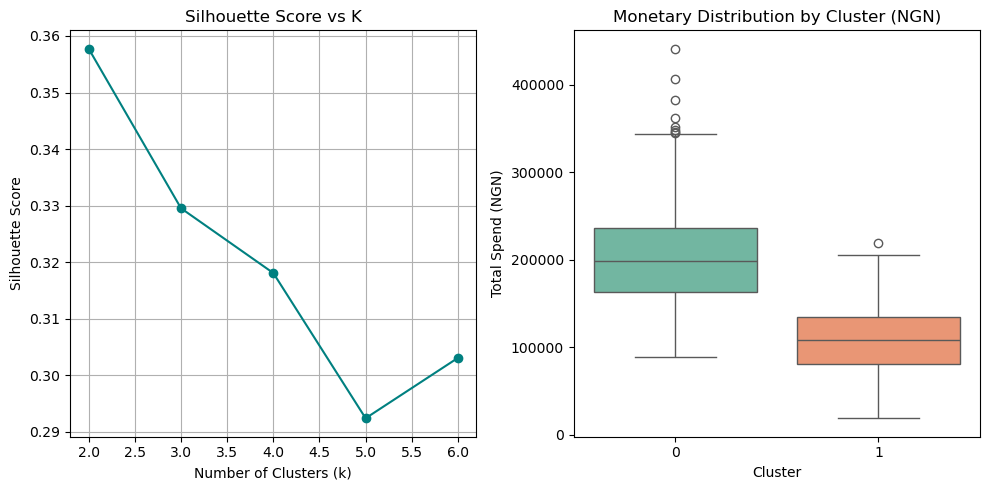

In [17]:
plt.figure(figsize=(10, 5))

# Plot Silhouette Score vs K
plt.subplot(1, 2, 1)
plt.plot(k_range, silhouette_scores, marker='o', color='teal')
plt.title('Silhouette Score vs K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

# Plot Spend by Cluster
plt.subplot(1, 2, 2)
sns.boxplot(x='Cluster', y='Monetary', data=rfm, palette='Set2')
plt.title('Monetary Distribution by Cluster (NGN)')
plt.ylabel('Total Spend (NGN)')

plt.tight_layout()
plt.show()